In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

def sigmoid(x, lambda_param):
    return 1 / (1 + np.exp(-lambda_param * x))

def IPT_metric(ipt_x, ipt_y, n_pts):
    num_directions = ipt_x.shape[0]
    
    # Calculate the sum of L2-norms for each direction
    total_dist = 0
    for i in range(num_directions):
        total_dist += np.linalg.norm(ipt_x[i] - ipt_y[i])/n_pts

    return total_dist / num_directions

def EMD(ipt_x, ipt_y, n_pts):
    num_directions = ipt_x.shape[0]

    total_dist = 0
    for i in range(ipt_x.shape[0]):
        total_dist += np.sum(np.abs(ipt_x[i]/n_pts - ipt_y[i]/n_pts)) 
    return total_dist / num_directions


def pairwise_IPT(ects, n_pts, batch=100):
    N = ects.shape[0]
    pairwise_dist = np.zeros((N, N))

    for i in range(0, N, batch):
        print(f"Computing pairwise IPT distances for batch {i} to {min(i+batch, N)}...")
        batch_ects = ects[i:i+batch]

        diff = batch_ects[:, None] - ects[None]

        dir_norms = np.linalg.norm(diff, axis=-1)

        dists = dir_norms.mean(axis=-1)/n_pts

        pairwise_dist[i:i+batch] = dists
    return pairwise_dist

def pairwise_EMD(ects, n_pts, batch=100):
    N = ects.shape[0]
    pairwise_dist = np.zeros((N, N))

    for i in range(0, N, batch):
        print(f"Computing pairwise EMD distances for batch {i} to {min(i+batch, N)}...")
        batch_ects = ects[i:i+batch]

        diff = batch_ects[:, None] - ects[None]

        dir_norms = np.abs(diff).sum(axis=-1)

        dists = dir_norms.mean(axis=-1)/n_pts

        pairwise_dist[i:i+batch] = dists
    return pairwise_dist

class PointCloudPipeline:
    def __init__(self, num_directions=3, num_thresholds=32, radius=1.1, test_size=0.2):
        self.num_directions = num_directions
        self.num_thresholds = num_thresholds
        self.radius = radius
        self.test_size = test_size
        self.directions = self._generate_directions(self.num_directions)
        
        # Data and Features
        self.X_train, self.X_test = None, None
        self.y_train, self.y_test = None, None
        self.ect_train, self.ect_test = None, None
        
        # Classifiers
        self.rf_model = None
        self.svc_model = None

    def _generate_directions(self, n):
        """Generates n regular directions in 2D."""
        angles = np.linspace(0, 2*np.pi, n, endpoint=False)
        return np.stack((np.cos(angles), np.sin(angles)), axis=1)

    def load_and_preprocess(self, file_path):
        """Loads, splits, centers, and scales data."""
        data = np.load(file_path)
        X, y = data['points'], data['labels']
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=42
        )

        def scale_set(data):
            centered = data - data.mean(axis=1, keepdims=True)
            max_radii = np.max(np.linalg.norm(centered, axis=2, keepdims=True), axis=1, keepdims=True)
            return centered / max_radii

        self.X_train = scale_set(self.X_train)
        self.X_test = scale_set(self.X_test)
        return self

    # def _compute_ect(self, X):
    #     """Helper to compute ECT for a given dataset."""
    #     n_samples = X.shape[0]
    #     features = np.zeros((n_samples, self.num_directions, self.num_thresholds))
    #     for i in range(n_samples):
    #         for d_idx, d in enumerate(self.directions):
    #             dot_prods = np.dot(X[i], d)
    #             for th in range(self.num_thresholds):
    #                 a = -self.radius + (th/self.num_thresholds) * (2 * self.radius)
    #                 features[i, d_idx, th] = np.sum(dot_prods <= a)
    #     return features

    def _compute_ect(self, X):
        """
        Optimized ECT using vectorization and cumulative sums.
        X shape: (n_samples, n_points, 2)
        """
        n_samples, n_points, _ = X.shape
        thresholds = np.linspace(-self.radius, self.radius, self.num_thresholds)
        features = np.zeros((n_samples, self.num_directions, self.num_thresholds))

        for d_idx, d in enumerate(self.directions):
            # projections shape: (n_samples, n_points)
            projections = np.dot(X, d)
            
            for i in range(n_samples):
                bins = np.concatenate([[-np.inf], thresholds])
                counts, _ = np.histogram(projections[i], bins=bins)
                features[i, d_idx, :] = np.cumsum(counts)    
        return features



    # def _compute_sect(self, X, lambda_val=10.0):
    #     n_samples, n_points, _ = X.shape
    #     thresholds = np.linspace(-self.radius, self.radius, self.num_thresholds)
    #     features = np.zeros((n_samples, self.num_directions, self.num_thresholds))
        
    #     for d_idx, d in enumerate(self.directions):
    #         projections = np.dot(X, d) 
            
    #         for t_idx, t in enumerate(thresholds):
    #             val = 1.0 / (1.0 + np.exp(-lambda_val * (t - projections)))                
    #             features[:, d_idx, t_idx] = np.sum(val, axis=1)
                
    #     return features

    def _compute_sect(self, X, lambda_val=10.0, n_jobs=-1):
        """
        Parallelized SECT using joblib.
        n_jobs=-1 uses all available CPU cores.
        """
        n_samples, n_points, _ = X.shape
        thresholds = np.linspace(-self.radius, self.radius, self.num_thresholds)
        
        # Define the work for a single sample
        def process_sample(sample_points):
            # Shape for one sample: (num_directions, num_thresholds)
            sample_features = np.zeros((self.num_directions, self.num_thresholds))
            for d_idx, d in enumerate(self.directions):
                projections = np.dot(sample_points, d)
                for t_idx, t in enumerate(thresholds):
                    # Sigmoid-based smoothing
                    val = 1.0 / (1.0 + np.exp(-lambda_val * (t - projections)))
                    sample_features[d_idx, t_idx] = np.sum(val)
            return sample_features

        # Execute in parallel
        results = Parallel(n_jobs=n_jobs)(
            delayed(process_sample)(X[i]) for i in range(n_samples)
        )
        
        # Stack results back into (n_samples, n_directions, n_thresholds)
        return np.array(results)
    

    def extract_features(self, use_smooth=False, lambda_val=10.0):
        """Computes and flattens features. use_smooth=True uses SECT."""
        mode = "SECT (Smooth)" if use_smooth else "ECT (Discrete)"
        print(f"Extracting {mode} features...")
        
        if use_smooth:
            self.ect_train = self._compute_sect(self.X_train, lambda_val)
            self.ect_test = self._compute_sect(self.X_test, lambda_val)
        else:
            self.ect_train = self._compute_ect(self.X_train)
            self.ect_test = self._compute_ect(self.X_test)
        return self
    
    def fit_and_evaluate_knn_classifier(self, k, metric='EMD'):
        """
        Classifies using k-Nearest Neighbors with SWD-like metrics.
        """
        print(f"Evaluating k-Nearest Neighbors Classifier (Metric: {metric})...")
        
        y_pred = []

        for i in range(self.ect_test.shape[0]):
            current_sample = self.ect_test[i]
            distances = []
            
            for j in range(self.ect_train.shape[0]):
                if metric == 'EMD':
                    dist = EMD(current_sample, self.ect_train[j], self.X_train.shape[1])
                else:
                    dist = IPT_metric(current_sample, self.ect_train[j], self.X_train.shape[1])
                distances.append((dist, self.y_train[j]))
                
            distances.sort(key=lambda x: x[0])  # Sort by distance
            neighbors = distances[:k]  # Get k nearest neighbors
            neighbor_labels = [label for _, label in neighbors]
            predicted_label = max(set(neighbor_labels), key=neighbor_labels.count)  # Majority vote
            #print(f"Sample {i}: Predicted={predicted_label}, True={self.y_test[i]}")
            y_pred.append(predicted_label)

        y_pred = np.array(y_pred)
        print(classification_report(self.y_test, y_pred))
        return y_pred
    
    def fit_and_evaluate_SWD_classifier(self, metric='EMD'):
        """
        Classifies using a Nearest Prototype approach with SWD-like metrics.
        """
        print(f"Evaluating Nearest Prototype Classifier (Metric: {metric})...")
        
        # Calculate Mean ECT for each class: shape (n_classes, n_dirs, n_thresholds)
        unique_labels = np.unique(self.y_train)
        prototypes = []
        for label in unique_labels:
            proto = wasserstein_barycenter_1d_hist(self.ect_train[self.y_train == label])
            prototypes.append(proto)
        prototypes = np.array(prototypes)

        y_pred = []
        n_pts = self.X_train.shape[1] # Assuming (samples, points, coords)

        for i in range(self.ect_test.shape[0]):
            current_sample = self.ect_test[i]
            distances = []
            
            for proto in prototypes:
                if metric == 'EMD':
                    dist = EMD(current_sample, proto, n_pts)
                else:
                    dist = IPT_metric(current_sample, proto, n_pts)
                distances.append(dist)
                
            y_pred.append(unique_labels[np.argmin(distances)])

        y_pred = np.array(y_pred)
        print(classification_report(self.y_test, y_pred))
        return y_pred


    def fit_random_forest(self, n_estimators=100, max_depth=None):
        """Fits a Random Forest on flattened ECT data."""
        print("Fitting Random Forest...")
        self.rf_model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        train_features = self.ect_train.reshape(self.ect_train.shape[0], -1)
        self.rf_model.fit(train_features, self.y_train)
        return self

    def fit_svc(self, C=1.0, kernel='rbf'):
        """Fits an SVC on flattened ECT data."""
        print("Fitting SVC...")
        self.svc_model = SVC(C=C, kernel=kernel)
        train_features = self.ect_train.reshape(self.ect_train.shape[0], -1)
        self.svc_model.fit(train_features, self.y_train)
        return self

    def evaluate(self, model_type='rf'):
        """Tests the chosen model on the test ECT data."""
        model = self.rf_model if model_type == 'rf' else self.svc_model
        if model is None:
            raise ValueError(f"Model '{model_type}' has not been trained yet.")
        
        test_features = self.ect_test.reshape(self.ect_test.shape[0], -1)
        y_pred = model.predict(test_features)
        acc = accuracy_score(self.y_test, y_pred)
        print(f"--- {model_type.upper()} Evaluation ---")
        print(f"Accuracy: {acc:.4f}")
        print(classification_report(self.y_test, y_pred))
        return acc

## Ablation Study
Increasing the number of directions

In [2]:
# Example Execution:
pipeline = PointCloudPipeline(num_directions=9, num_thresholds=32)
pipeline.load_and_preprocess('mnist_512_pc.npz')
pipeline.extract_features()

# Run Random Forest
pipeline.fit_random_forest(n_estimators=200)
pipeline.evaluate(model_type='rf')

# Run SVC
pipeline.fit_svc(C=10.0)
pipeline.evaluate(model_type='svc')

Extracting features...
Fitting Random Forest...
--- RF Evaluation ---
Accuracy: 0.9473
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1175
           1       0.98      0.98      0.98      1322
           2       0.94      0.96      0.95      1174
           3       0.92      0.92      0.92      1219
           4       0.95      0.95      0.95      1176
           5       0.95      0.93      0.94      1104
           6       0.96      0.98      0.97      1177
           7       0.95      0.95      0.95      1299
           8       0.92      0.92      0.92      1160
           9       0.92      0.91      0.92      1194

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000

Fitting SVC...
--- SVC Evaluation ---
Accuracy: 0.9302
              precision    recall  f1-score   support

           0       0.95      0.97      0.96 

0.9301666666666667

In [3]:
# Example Execution:
pipeline = PointCloudPipeline(num_directions=15, num_thresholds=32)
pipeline.load_and_preprocess('mnist_512_pc.npz')
pipeline.extract_features()

# Run Random Forest
pipeline.fit_random_forest(n_estimators=200)
pipeline.evaluate(model_type='rf')

# Run SVC
pipeline.fit_svc(C=10.0)
pipeline.evaluate(model_type='svc')

Extracting features...
Fitting Random Forest...
--- RF Evaluation ---
Accuracy: 0.9477
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1175
           1       0.98      0.98      0.98      1322
           2       0.94      0.96      0.95      1174
           3       0.92      0.92      0.92      1219
           4       0.95      0.95      0.95      1176
           5       0.94      0.93      0.94      1104
           6       0.96      0.98      0.97      1177
           7       0.95      0.95      0.95      1299
           8       0.93      0.92      0.92      1160
           9       0.92      0.91      0.92      1194

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000

Fitting SVC...
--- SVC Evaluation ---
Accuracy: 0.9309
              precision    recall  f1-score   support

           0       0.95      0.96      0.96 

0.9309166666666666

## IPT of the MNIST data

Visualizing the IPT

In [3]:
pipeline = PointCloudPipeline(num_directions=15, num_thresholds=32)
pipeline.load_and_preprocess('mnist_512_pc.npz')
pipeline.extract_features(use_smooth=False, lambda_val=10.0)

Extracting ECT (Discrete) features...


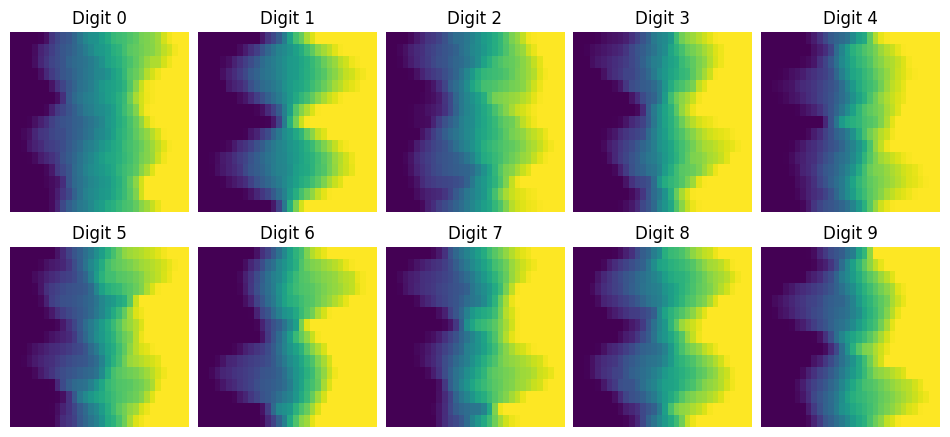

In [28]:
fig, ax = plt.subplots(2, 5, figsize=(12, 5), gridspec_kw={'hspace': 0.2})
label = 0
for i in range(5):
    ax[0, i].imshow(pipeline.ect_train[pipeline.y_train == label][0].reshape(pipeline.num_directions, pipeline.num_thresholds), aspect = 'auto')
    ax[0, i].set_title(f'Digit {label}')
    ax[0, i].axis('off')
    ax[1, i].imshow(pipeline.ect_train[pipeline.y_train == label+5][0].reshape(pipeline.num_directions, pipeline.num_thresholds), aspect = 'auto')
    ax[1, i].set_title(f'Digit {label+5}')
    ax[1, i].axis('off')
    label += 1
plt.subplots_adjust(hspace=0.2, wspace=0.05, top=0.9)
plt.show()

## IPT as a feature vector

1. Number of directions = 9
2. Number of thresholds = 16

In [29]:
# Example Execution:
pipeline = PointCloudPipeline(num_directions=9, num_thresholds=16)
pipeline.load_and_preprocess('mnist_512_pc.npz')
pipeline.extract_features(use_smooth=False, lambda_val=10.0)

Extracting ECT (Discrete) features...


In [30]:
# Run Random Forest
pipeline.fit_random_forest(n_estimators=200)
pipeline.evaluate(model_type='rf')

# Run SVC
pipeline.fit_svc(C=10.0)
pipeline.evaluate(model_type='svc')

Fitting Random Forest...
--- RF Evaluation ---
Accuracy: 0.9467
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1175
           1       0.98      0.98      0.98      1322
           2       0.94      0.96      0.95      1174
           3       0.92      0.92      0.92      1219
           4       0.94      0.95      0.94      1176
           5       0.95      0.93      0.94      1104
           6       0.96      0.98      0.97      1177
           7       0.96      0.95      0.95      1299
           8       0.92      0.92      0.92      1160
           9       0.91      0.91      0.91      1194

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000

Fitting SVC...
--- SVC Evaluation ---
Accuracy: 0.9267
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1175
           1 

0.9266666666666666

1. Num Directions = 15
2. Num Thresholds = 16

In [31]:
pipeline = PointCloudPipeline(num_directions=15, num_thresholds=16)
pipeline.load_and_preprocess('mnist_512_pc.npz')
pipeline.extract_features(use_smooth=False, lambda_val=10.0)

Extracting ECT (Discrete) features...


In [32]:
# Run Random Forest
pipeline.fit_random_forest(n_estimators=200)
pipeline.evaluate(model_type='rf')

# Run SVC
pipeline.fit_svc(C=10.0)
pipeline.evaluate(model_type='svc')

Fitting Random Forest...
--- RF Evaluation ---
Accuracy: 0.9472
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1175
           1       0.98      0.98      0.98      1322
           2       0.94      0.96      0.95      1174
           3       0.93      0.92      0.92      1219
           4       0.95      0.95      0.95      1176
           5       0.95      0.93      0.94      1104
           6       0.96      0.98      0.97      1177
           7       0.95      0.95      0.95      1299
           8       0.93      0.93      0.93      1160
           9       0.91      0.91      0.91      1194

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000

Fitting SVC...
--- SVC Evaluation ---
Accuracy: 0.9268
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1175
           1 

0.9268333333333333

1. Num Directions = 3
2. Num Thresholds = 16

In [33]:
pipeline = PointCloudPipeline(num_directions=3, num_thresholds=16)
pipeline.load_and_preprocess('mnist_512_pc.npz')
pipeline.extract_features(use_smooth=False, lambda_val=10.0)

Extracting ECT (Discrete) features...


In [34]:
# Run Random Forest
pipeline.fit_random_forest(n_estimators=200)
pipeline.evaluate(model_type='rf')

# Run SVC
pipeline.fit_svc(C=10.0)
pipeline.evaluate(model_type='svc')

Fitting Random Forest...
--- RF Evaluation ---
Accuracy: 0.9163
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      1175
           1       0.96      0.98      0.97      1322
           2       0.89      0.94      0.91      1174
           3       0.91      0.89      0.90      1219
           4       0.92      0.91      0.91      1176
           5       0.91      0.90      0.91      1104
           6       0.94      0.96      0.95      1177
           7       0.90      0.90      0.90      1299
           8       0.89      0.87      0.88      1160
           9       0.88      0.87      0.88      1194

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000

Fitting SVC...
--- SVC Evaluation ---
Accuracy: 0.8746
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      1175
           1 

0.8745833333333334

1. Number of directions = 9
2. Number of thresholds = 32

In [35]:
pipeline = PointCloudPipeline(num_directions=9, num_thresholds=32)
pipeline.load_and_preprocess('mnist_512_pc.npz')
pipeline.extract_features(use_smooth=False, lambda_val=10.0)

Extracting ECT (Discrete) features...


In [36]:
# Run Random Forest
pipeline.fit_random_forest(n_estimators=200)
pipeline.evaluate(model_type='rf')

# Run SVC
pipeline.fit_svc(C=10.0)
pipeline.evaluate(model_type='svc')

Fitting Random Forest...
--- RF Evaluation ---
Accuracy: 0.9470
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1175
           1       0.98      0.98      0.98      1322
           2       0.94      0.96      0.95      1174
           3       0.92      0.92      0.92      1219
           4       0.95      0.95      0.95      1176
           5       0.94      0.93      0.94      1104
           6       0.97      0.98      0.97      1177
           7       0.95      0.95      0.95      1299
           8       0.92      0.92      0.92      1160
           9       0.92      0.91      0.92      1194

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000

Fitting SVC...
--- SVC Evaluation ---
Accuracy: 0.9294
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1175
           1 

0.9294166666666667

1. Num Directions = 3
2. Num Thresholds = 32

In [37]:
pipeline = PointCloudPipeline(num_directions=3, num_thresholds=32)
pipeline.load_and_preprocess('mnist_512_pc.npz')
pipeline.extract_features(use_smooth=False, lambda_val=10.0)

Extracting ECT (Discrete) features...


In [38]:
# Run Random Forest
pipeline.fit_random_forest(n_estimators=200)
pipeline.evaluate(model_type='rf')

# Run SVC
pipeline.fit_svc(C=10.0)
pipeline.evaluate(model_type='svc')

Fitting Random Forest...
--- RF Evaluation ---
Accuracy: 0.9170
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      1175
           1       0.96      0.98      0.97      1322
           2       0.88      0.94      0.91      1174
           3       0.91      0.88      0.89      1219
           4       0.91      0.91      0.91      1176
           5       0.91      0.91      0.91      1104
           6       0.95      0.96      0.95      1177
           7       0.90      0.91      0.90      1299
           8       0.89      0.87      0.88      1160
           9       0.89      0.87      0.88      1194

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000

Fitting SVC...
--- SVC Evaluation ---
Accuracy: 0.8792
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      1175
           1 

0.87925

## ML model on the Point Cloud

In [3]:
pipeline = PointCloudPipeline(num_directions=3, num_thresholds=32)
pipeline.load_and_preprocess('mnist_512_pc.npz')

In [5]:
X_train = pipeline.X_train
y_train = pipeline.y_train

X_test = pipeline.X_test
y_test = pipeline.y_test

In [8]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

In [9]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8552
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1175
           1       0.90      0.94      0.92      1322
           2       0.90      0.84      0.87      1174
           3       0.83      0.78      0.81      1219
           4       0.83      0.92      0.87      1176
           5       0.89      0.79      0.84      1104
           6       0.92      0.92      0.92      1177
           7       0.85      0.90      0.87      1299
           8       0.74      0.75      0.74      1160
           9       0.81      0.80      0.81      1194

    accuracy                           0.86     12000
   macro avg       0.86      0.85      0.85     12000
weighted avg       0.86      0.86      0.85     12000



In [ ]:
svm_model = SVC(C=10, kernel='rbf')
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred))

## The Probability Distributions

In [8]:
pipeline = PointCloudPipeline(num_directions=3, num_thresholds=32)
pipeline.load_and_preprocess('mnist_512_pc.npz')
pipeline.extract_features(use_smooth=False, lambda_val=10.0)

Extracting ECT (Discrete) features...


In [6]:
def get_pdf(ipt_x, n_pts):
    p = np.zeros(ipt_x.shape)
    for i in range(ipt_x.shape[0]):
        for j in range(ipt_x.shape[1]):
            p[i][j] = ipt_x[i][j] - ipt_x[i][j-1] if j > 0 else ipt_x[i][j]
    p /= n_pts
    return p

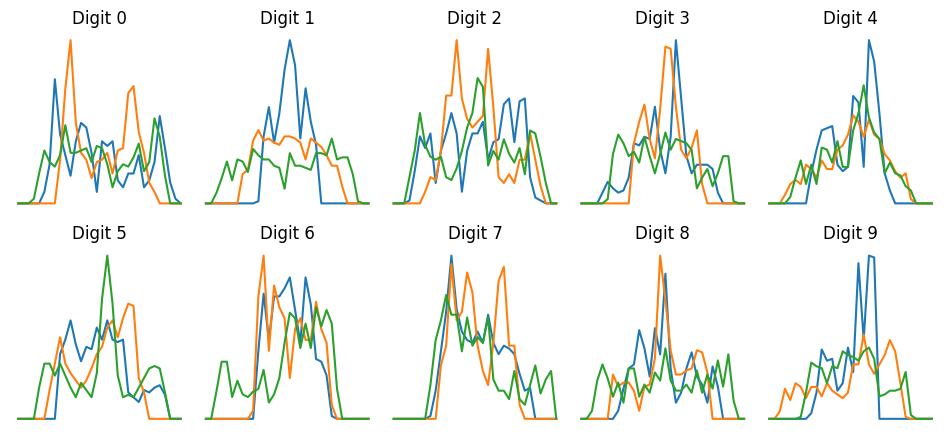

In [9]:
fig, ax = plt.subplots(2, 5, figsize=(12, 5), gridspec_kw={'hspace': 0.2})
label = 0
for i in range(5):
    ipt_up = pipeline.ect_train[pipeline.y_train == label][0]
    ipt_pdf = get_pdf(ipt_up, pipeline.X_train.shape[1])
    for j in range(pipeline.num_directions):
        ax[0, i].plot(ipt_pdf[j], label=f'Direction {j}')
    ax[0, i].set_title(f'Digit {label}')
    ax[0, i].axis('off')
    ipt_down = pipeline.ect_train[pipeline.y_train == label+5][0]
    ipt_pdf = get_pdf(ipt_down, pipeline.X_train.shape[1])
    for j in range(pipeline.num_directions):
        ax[1, i].plot(ipt_pdf[j], label=f'Direction {j}')
    ax[1, i].set_title(f'Digit {label+5}')
    ax[1, i].axis('off')
    label += 1
plt.subplots_adjust(hspace=0.2, wspace=0.05, top=0.9)
plt.show()

### Smooth Version 

In [5]:
pipeline = PointCloudPipeline(num_directions=3, num_thresholds=32)
pipeline.load_and_preprocess('mnist_512_pc.npz')
pipeline.extract_features(use_smooth=True, lambda_val=10.0)

Extracting SECT (Smooth) features...


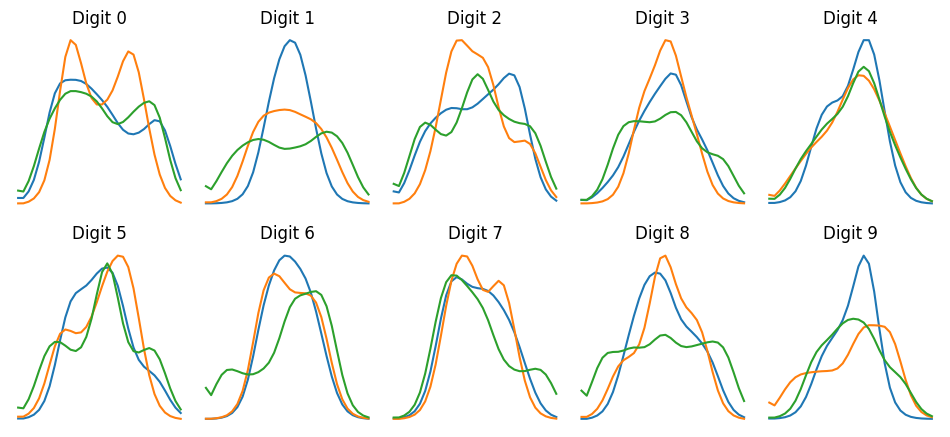

In [7]:
fig, ax = plt.subplots(2, 5, figsize=(12, 5), gridspec_kw={'hspace': 0.2})
label = 0
for i in range(5):
    ipt_up = pipeline.ect_train[pipeline.y_train == label][0]
    ipt_pdf = get_pdf(ipt_up, pipeline.X_train.shape[1])
    for j in range(pipeline.num_directions):
        ax[0, i].plot(ipt_pdf[j], label=f'Direction {j}')
    ax[0, i].set_title(f'Digit {label}')
    ax[0, i].axis('off')
    ipt_down = pipeline.ect_train[pipeline.y_train == label+5][0]
    ipt_pdf = get_pdf(ipt_down, pipeline.X_train.shape[1])
    for j in range(pipeline.num_directions):
        ax[1, i].plot(ipt_pdf[j], label=f'Direction {j}')
    ax[1, i].set_title(f'Digit {label+5}')
    ax[1, i].axis('off')
    label += 1
plt.subplots_adjust(hspace=0.2, wspace=0.05, top=0.9)
plt.show()

## Wasserstein Barycenter

In [223]:
# Example Execution:
pipeline = PointCloudPipeline(num_directions=9, num_thresholds=20)
pipeline.load_and_preprocess('mnist_512_pc.npz')
pipeline.extract_features(use_smooth=True, lambda_val=10.0)

Extracting SECT (Smooth) features...


In [216]:
def get_pdf(ipt_x, n_pts):
    p = np.zeros(ipt_x.shape)
    for i in range(ipt_x.shape[0]):
        for j in range(ipt_x.shape[1]):
            p[i][j] = ipt_x[i][j] - ipt_x[i][j-1] if j > 0 else ipt_x[i][j]
    #p /= n_pts
    return p

In [217]:
def compute_wasserstein_barycenter(A):
    """
    Compute the Wasserstein barycenter of a set of empirical CDFs.
    A : (n, num_thresholds) array of CDFs
    """
    num_thresholds = A.shape[1]
    n = A.shape[0]

    # The actual domain values (X ranges from -1 to 1)
    x_thresholds = np.linspace(-1, 1, num_thresholds) 

    p_grid = np.linspace(0, 512, 100) 

    quantiles = np.zeros((n, len(p_grid)))
    for i in range(n):
        indices = np.searchsorted(A[i], p_grid)
        indices = np.clip(indices, 0, num_thresholds - 1)
        quantiles[i] = x_thresholds[indices]
        
    barycenter_quantile = np.mean(quantiles, axis=0)
    barycenter_cdf = np.interp(x_thresholds, barycenter_quantile, p_grid)
    return barycenter_cdf

In [224]:
def Barycenter_ECTs(ect_train, y_train, num_directions, num_thresholds):
    Barycenters = np.zeros((len(np.unique(y_train)), num_directions, num_thresholds))
    for label in range(len(np.unique(y_train))):
        C = ect_train[y_train == label]
        for i in range(num_directions):
            A = C[:,i,:]
            Barycenters[label][i] = compute_wasserstein_barycenter(A)
    return Barycenters

ect_train = pipeline.ect_train
y_train = pipeline.y_train
num_directions = pipeline.num_directions
num_thresholds = pipeline.num_thresholds
Barycenters = Barycenter_ECTs(ect_train, y_train, num_directions, num_thresholds)

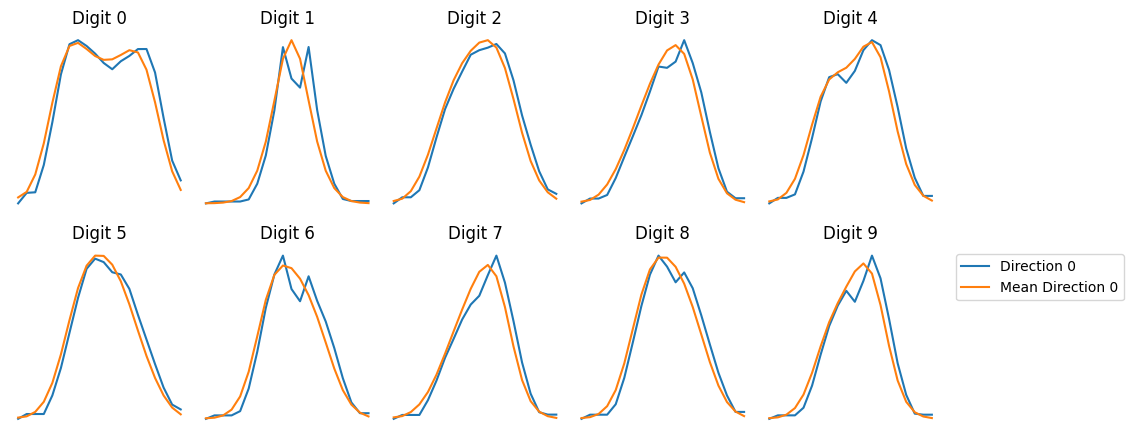

In [225]:
## Mean PDF vs Barycenter
fig, ax = plt.subplots(2, 5, figsize=(12, 5), gridspec_kw={'hspace': 0.2})
j = 0
for i in range(5):
    ipt_up = Barycenters[i]
    ipt_pdf = get_pdf(ipt_up, pipeline.X_train.shape[1])
    
    ax[0][i].plot(ipt_pdf[j], label=f'Direction {j}')
    mean_cdf = ect_train[y_train == i].mean(axis=0)[j]
    ax[0][i].plot([mean_cdf[k] - mean_cdf[k-1] if k > 0 else mean_cdf[k] for k in range(len(mean_cdf))], label=f'Mean Direction {j}')
    ax[0][i].set_title(f'Digit {i}')
    ax[0][i].axis('off')

    ipt_down = Barycenters[i+5]
    ipt_pdf = get_pdf(ipt_down, pipeline.X_train.shape[1])

    ax[1][i].plot(ipt_pdf[j], label=f'Direction {j}')
    mean_cdf = ect_train[y_train == i+5].mean(axis=0)[j]
    ax[1][i].plot([mean_cdf[k] - mean_cdf[k-1] if k > 0 else mean_cdf[k] for k in range(len(mean_cdf))], label=f'Mean Direction {j}')
    ax[1][i].set_title(f'Digit {i+5}')
    ax[1][i].axis('off')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.subplots_adjust(hspace=0.2, wspace=0.05, top=0.9)
plt.show()

In [226]:
from scipy.stats import entropy
import numpy as np

def Barycenter_classifier_kl_div(pipeline):
    """
    Classifier using the kl divergence to compare the barycenter and the test sample"""
    labels = len(np.unique(pipeline.y_train))
    epsilon = 1e-10 
    P_bary_list = []

    for label in range(labels):
        C = pipeline.ect_train[pipeline.y_train == label]
        barycenter_label = np.zeros((pipeline.num_directions, pipeline.num_thresholds))
        for i in range(pipeline.num_directions):
            A = C[:, i, :]
            barycenter_label[i] = compute_wasserstein_barycenter(A)

        P_bary_list.append(get_pdf(barycenter_label, 512))
        
    P_bary = np.array(P_bary_list) + epsilon
    
    y_pred = []
    
    for test in pipeline.ect_test:
        P_test = get_pdf(test, 512) + epsilon 
        kl_divergence = np.sum(P_test * np.log(P_test / P_bary), axis=(1, 2))
        #print(f'label wise divergence: {kl_divergence}") for test sample ') 
        y_pred.append(np.argmin(kl_divergence))
    return y_pred

def Barycenter_classifier(pipeline):
    unique_labels = np.unique(pipeline.y_train)
    barycenters = {} 

    for label in unique_labels:
        C = pipeline.ect_train[pipeline.y_train == label]
        label_barycenter = np.zeros((pipeline.num_directions, pipeline.num_thresholds))
        
        for i in range(pipeline.num_directions):
            A = C[:, i, :]
            label_barycenter[i] = compute_wasserstein_barycenter(A)
        barycenters[label] = label_barycenter
    
    y_pred = []
    
    for test in pipeline.ect_test:
        distances = []
        for label in unique_labels:
            d = EMD(test, barycenters[label], 512)
            distances.append(d)
        best_index = np.argmin(distances)
        y_pred.append(unique_labels[best_index])
        
    return y_pred

In [227]:
y_pred = Barycenter_classifier(pipeline)

acc = accuracy_score(pipeline.y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(pipeline.y_test, y_pred))

Accuracy: 0.6318
              precision    recall  f1-score   support

           0       0.79      0.79      0.79      1175
           1       0.70      0.84      0.77      1322
           2       0.81      0.53      0.64      1174
           3       0.44      0.58      0.50      1219
           4       0.57      0.70      0.63      1176
           5       0.51      0.36      0.42      1104
           6       0.79      0.76      0.78      1177
           7       0.78      0.62      0.69      1299
           8       0.45      0.42      0.43      1160
           9       0.59      0.66      0.62      1194

    accuracy                           0.63     12000
   macro avg       0.64      0.63      0.63     12000
weighted avg       0.64      0.63      0.63     12000



In [228]:
y_pred = Barycenter_classifier_kl_div(pipeline)

acc = accuracy_score(pipeline.y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(pipeline.y_test, y_pred))

Accuracy: 0.6866
              precision    recall  f1-score   support

           0       0.80      0.80      0.80      1175
           1       0.83      0.76      0.79      1322
           2       0.73      0.75      0.74      1174
           3       0.52      0.68      0.59      1219
           4       0.59      0.81      0.68      1176
           5       0.64      0.43      0.51      1104
           6       0.90      0.73      0.81      1177
           7       0.88      0.68      0.76      1299
           8       0.50      0.59      0.54      1160
           9       0.67      0.62      0.64      1194

    accuracy                           0.69     12000
   macro avg       0.70      0.68      0.69     12000
weighted avg       0.71      0.69      0.69     12000



## Multiple Prototypes